# R04. Contest Choice

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\James\Documents\MLB\Data\A09. DraftKings\3. Payouts\Payouts 125294380.csv")

In [44]:
import pandas as pd
import glob
import os

payout_folder = r"C:\Users\James\Documents\MLB\Data\A09. DraftKings\3. Payouts"
entry_results_folder = r"C:\Users\James\Documents\MLB\Data\A09. DraftKings\5. Entry Results"

files = glob.glob(os.path.join(payout_folder, "*.csv"))

results = []

for f in files:
    df = pd.read_csv(f)

    contest_key = df['contestKey'].iloc[0]

    # ---------------------------------
    # Get actual entry count
    # ---------------------------------
    entry_file = os.path.join(
        entry_results_folder,
        f"Entry Results {int(contest_key)}.csv"
    )

    if os.path.exists(entry_file):
        entry_df = pd.read_csv(entry_file, encoding='iso-8859-1')
        actual_entries = len(entry_df)
        average_score = entry_df['Points'].mean() if 'Points' in entry_df.columns else None
        std_score = entry_df['Points'].std() if 'Points' in entry_df.columns else None
    else:
        actual_entries = None
        average_score = None
        std_score = None

    # ---------------------------------
    # Clean payout safely
    # ---------------------------------
    df['payout_clean'] = (
        df['payoutDescription']
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.extract(r'(\$?\d+\.?\d*)')[0]
            .str.replace('$', '', regex=False)
            .astype(float)
            .fillna(0.0)
    )

    df['num_positions'] = df['maxPosition'] - df['minPosition'] + 1
    df['row_payout'] = df['num_positions'] * df['payout_clean']

    total_payout = df['row_payout'].sum()

    # ---------------------------------
    # Contest-level info
    # ---------------------------------
    contest_info = {
        'contestKey': contest_key,
        'contestName': df['name'].iloc[0],
        'entryFee': df['entryFee'].iloc[0],
        'configured_entries': df['entries'].iloc[0],
        'actual_entries': actual_entries,
        'average_score': average_score,
        'std_score': std_score,
        'maximumEntriesPerUser': df['maximumEntriesPerUser'].iloc[0] if 'maximumEntriesPerUser' in df else None,
        'draftGroupId': df['draftGroupId'].iloc[0] if 'draftGroupId' in df else None,
        'contestStartTime': df['contestStartTime'].iloc[0] if 'contestStartTime' in df else None,
    }

    if actual_entries and actual_entries > 0:
        total_entry_fees = actual_entries * contest_info['entryFee']
        ev_ratio = total_payout / total_entry_fees
    else:
        total_entry_fees = None
        ev_ratio = None

    contest_info.update({
        'total_entry_fees': total_entry_fees,
        'total_payout': total_payout,
        'ev_ratio': ev_ratio,
        'rake_pct': None if ev_ratio is None else 1 - ev_ratio
    })

    results.append(contest_info)

final_df = pd.DataFrame(results)


In [45]:
final_df.query('actual_entries > 100').query('ev_ratio < 1').sort_values('ev_ratio', ascending=False)

,contestKey,contestName,entryFee,configured_entries,actual_entries,average_score,std_score,maximumEntriesPerUser,draftGroupId,contestStartTime,total_entry_fees,total_payout,ev_ratio,rake_pct
13730,182114361,MLB $2K Solo Shot (Turbo),1.0,397,2002.0,121.270129,34.213805,20,133888,2025-09-15T22:40:00.0000000Z,2002.0,2000.0,0.999001,0.000999
5402,163102336,MLB $15.6K Slap Hitter [$1.5K to 1st],66.0,23,237.0,97.320464,25.200704,8,109272,2024-06-29T23:15:00.0000000Z,15642.0,15600.0,0.997315,0.002685
13466,181352002,MLB $60K Relay Throw [$20K to 1st] (Night),15.0,641,4011.0,76.056819,14.491244,141,133324,2025-09-03T01:40:00.0000000Z,60165.0,60000.0,0.997258,0.002742
13977,182648331,MLB $60K Bat Flip [$20K to 1st],18.0,82,3345.0,82.398296,20.289961,117,134631,2025-09-27T23:15:00.0000000Z,60210.0,60000.0,0.996512,0.003488
10567,175364914,MLB $80K Batter's Eye [$20K to 1st],88.0,100,913.0,111.217470,30.643940,30,124672,2025-03-31T23:05:00.0000000Z,80344.0,80000.0,0.995718,0.004282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11273,176636013,MLB $35K Four-Seamer [20 Entry Max],4.0,922,10404.0,102.866796,29.137431,20,126976,2025-05-09T23:05:00.0000000Z,41616.0,35000.0,0.841023,0.158977
13018,179961503,MLB $20K Moonshot,3.0,1179,7927.0,81.292273,25.280507,20,132061,2025-08-11T23:05:00.0000000Z,23781.0,20000.0,0.841008,0.158992
11347,176738872,MLB $20K Moonshot,3.0,1215,7927.0,101.869118,21.282442,20,127268,2025-05-12T23:10:00.0000000Z,23781.0,20000.0,0.841008,0.158992
2631,161655142,MLB $10K mini-MAX [150 Entry Max],0.5,6610,23781.0,82.339580,22.698498,150,106825,2024-05-16T22:40:00.0000000Z,11890.5,10000.0,0.841008,0.158992


In [47]:
final_df.query('actual_entries > 100').groupby('contestName').agg({
    'entryFee': 'mean',
    'actual_entries': 'median',
    'average_score': 'mean',
    'std_score': 'mean',
    'ev_ratio': 'median',
    'contestKey': 'count'
}).sort_values('ev_ratio', ascending=False).query('contestKey > 10')

,entryFee,actual_entries,average_score,std_score,ev_ratio,contestKey
contestName,,,,,,
MLB $10K Full Count [$2K to 1st],55.0,203.0,94.238058,24.123344,0.895656,13
MLB $15K Batter's Eye [$3K to 1st],88.0,193.0,94.217377,24.923562,0.883184,13
MLB $40K Batter's Eye [$10K to 1st],88.0,516.0,98.477495,25.583076,0.880902,70
MLB $20K Batter's Eye [$4K to 1st],88.0,258.0,96.958283,26.966712,0.880902,14
MLB $50K Batter's Eye [$10K to 1st],88.0,645.0,96.705879,25.706047,0.880902,52
...,...,...,...,...,...,...
MLB $75K MEGA mini-MAX [150 Entry Max],3.0,29702.0,94.862074,25.731981,0.841694,25
MLB $60K MEGA mini-MAX [150 Entry Max],3.0,23763.0,95.170590,26.358991,0.841645,24
MLB $50K MEGA mini-MAX [150 Entry Max],3.0,19803.0,94.810038,25.137899,0.841623,31


In [48]:
agg_df = (
    final_df.query('actual_entries > 100').groupby('contestName').agg({
        'entryFee': 'mean',
        'actual_entries': 'median',
        'average_score': 'mean',
        'std_score': 'mean',
        'ev_ratio': 'median',
        'contestKey': 'count'
    }).sort_values('ev_ratio', ascending=False).query('contestKey > 10')
)


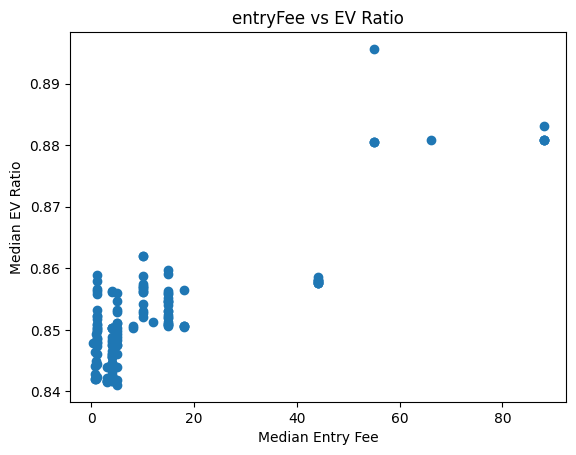

In [50]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(agg_df['entryFee'], agg_df['ev_ratio'])

plt.xlabel('Median Entry Fee')
plt.ylabel('Median EV Ratio')
plt.title('entryFee vs EV Ratio')

plt.show()


Conclusion:
- EV increases with entryFee

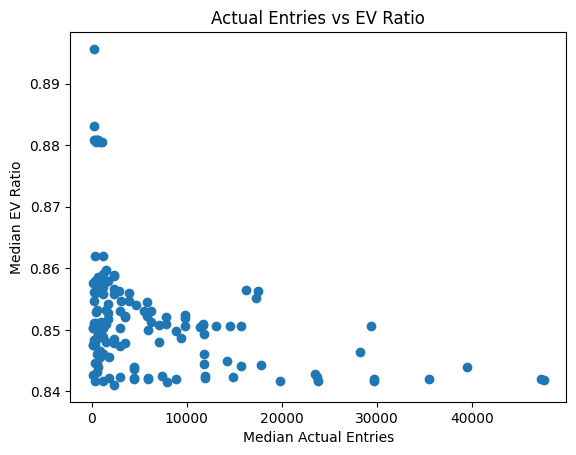

In [ ]:
plt.figure()
plt.scatter(agg_df['actual_entries'], agg_df['ev_ratio'])

plt.xlabel('Median Actual Entries')
plt.ylabel('Median EV Ratio')
plt.title('Actual Entries vs EV Ratio')

plt.show()


Conclusion:
- EV decreases with number of entries

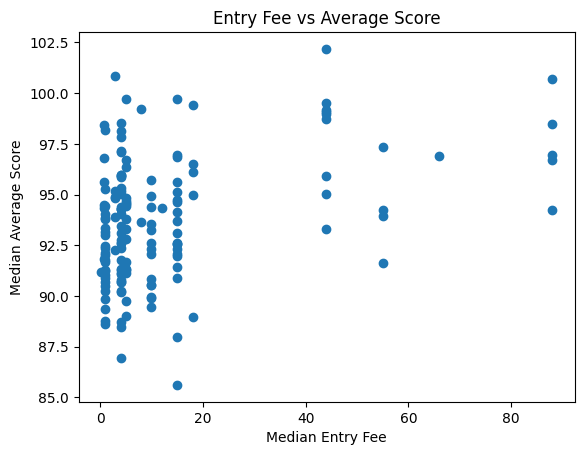

In [ ]:
plt.figure()
plt.scatter(agg_df['entryFee'], agg_df['average_score'])

plt.xlabel('Median Entry Fee')
plt.ylabel('Median Average Score')
plt.title('Entry Fee vs Average Score')


plt.show()


In [58]:
agg_df.query('contestKey > 30').groupby('entryFee')['average_score'].mean()

entryFee
0.723684     95.597195
0.727778     94.341205
0.738739     96.820108
0.796875     98.425474
0.887097     90.491211
1.000000     91.267044
3.000000     94.810038
4.000000     94.263845
5.000000     93.477795
10.000000    91.858636
15.000000    92.916982
18.000000    96.523279
44.000000    99.118184
88.000000    98.618145
Name: average_score, dtype: float64

Conclusion:
- Average score increases with entryFee. This may suggest that better players play in more expensive slates.
- Probably meaningless. Doesn't account for:
    - Slate size (maybe higher money contests are on bigger slates, which allow entrants to pick better players)
    - 0 point entries (maybe higher money contests are less likely to get 0 point entries)

Question: is it better to face the lower competition in cheap contests (if the competition really is lesser) or to get the higher EV in expensive contests?

Maybe see how  my lineups profit across cheap contests vs expensive ones of the same slate